In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

In [2]:
ticket=pd.read_csv(r"C:\Users\Aditya Kumar\OneDrive\Desktop\project\Ticket price prediction\Support_tickets.csv")
print(ticket.shape)
print(ticket.duplicated().sum())
print("total null values")
print(ticket.isnull().sum())

(50000, 33)
0
total null values
ticket_id                   0
day_of_week                 0
day_of_week_num             0
company_id                  0
company_size                0
company_size_cat            0
industry                    0
industry_cat                0
customer_tier               0
customer_tier_cat           0
org_users                   0
region                      0
region_cat                  0
past_30d_tickets            0
past_90d_incidents          0
product_area                0
product_area_cat            0
booking_channel             0
booking_channel_cat         0
reported_by_role            0
reported_by_role_cat        0
customers_affected          0
error_rate_pct              0
downtime_min                0
payment_impact_flag         0
security_incident_flag      0
data_loss_flag              0
has_runbook                 0
customer_sentiment        906
customer_sentiment_cat      0
description_length          0
priority                    0
priority

In [3]:
ticket=ticket.dropna(subset=['customer_sentiment'])
print(ticket['customer_sentiment'].isnull().sum())

numerical_col=ticket.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_col=ticket.select_dtypes(include=['object']).columns.tolist()
print('numerical columns ')
print(numerical_col)
print('\n categorical columns')
print(categorical_col)

0
numerical columns 
['ticket_id', 'day_of_week_num', 'company_id', 'company_size_cat', 'industry_cat', 'customer_tier_cat', 'org_users', 'region_cat', 'past_30d_tickets', 'past_90d_incidents', 'product_area_cat', 'booking_channel_cat', 'reported_by_role_cat', 'customers_affected', 'error_rate_pct', 'downtime_min', 'payment_impact_flag', 'security_incident_flag', 'data_loss_flag', 'has_runbook', 'customer_sentiment_cat', 'description_length', 'priority_cat']

 categorical columns
['day_of_week', 'company_size', 'industry', 'customer_tier', 'region', 'product_area', 'booking_channel', 'reported_by_role', 'customer_sentiment', 'priority']


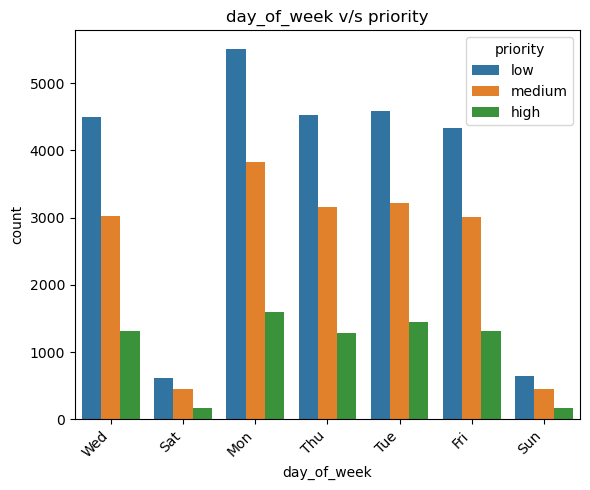

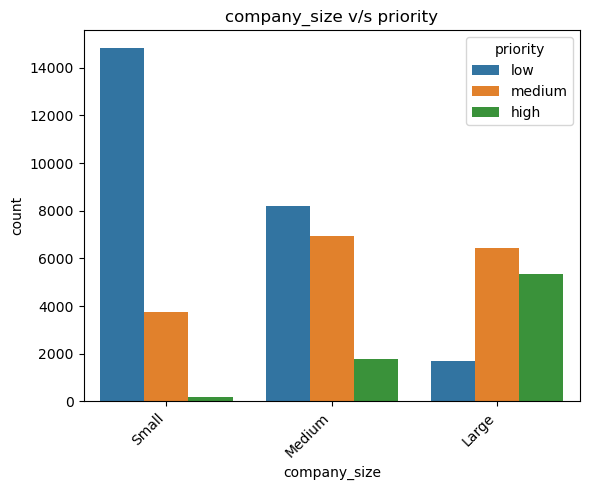

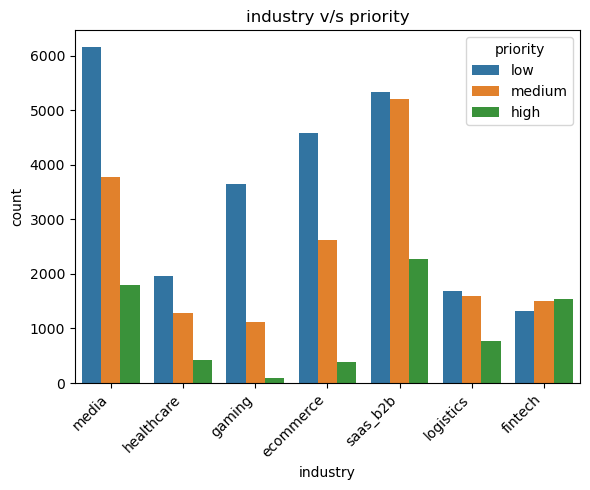

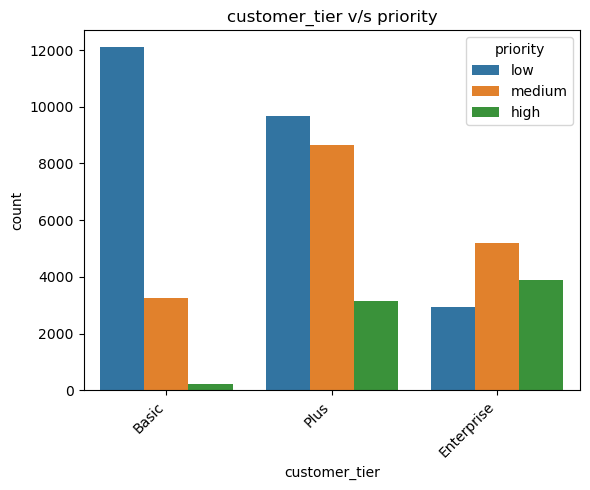

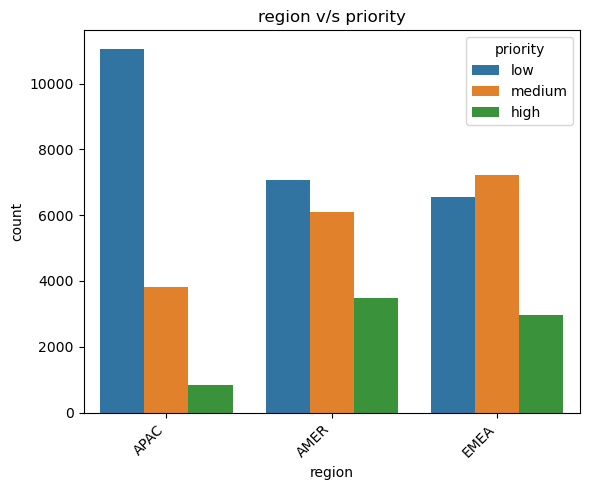

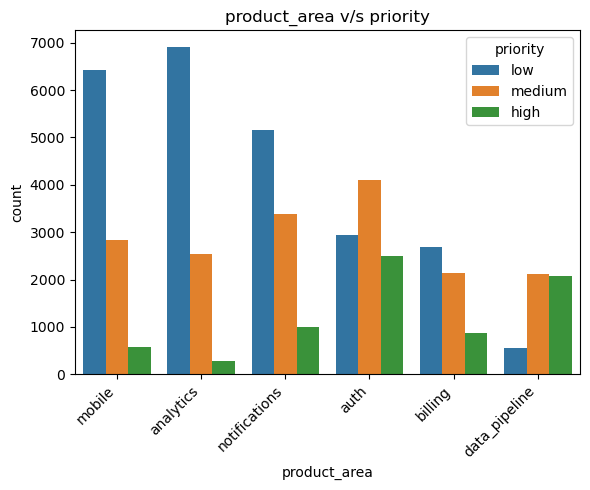

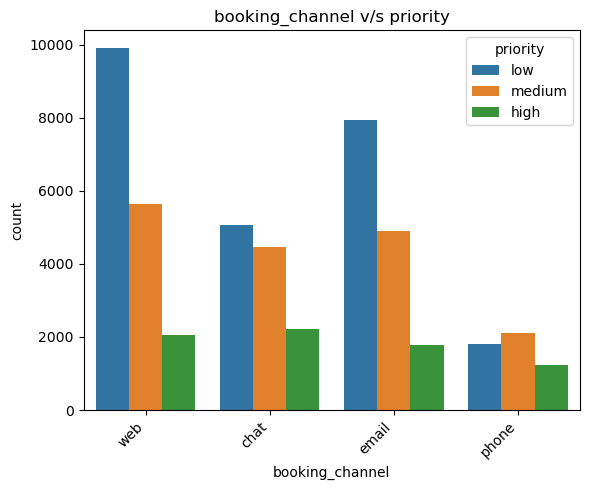

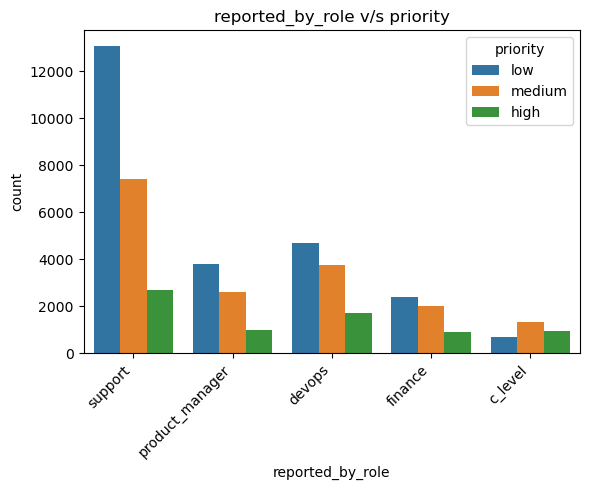

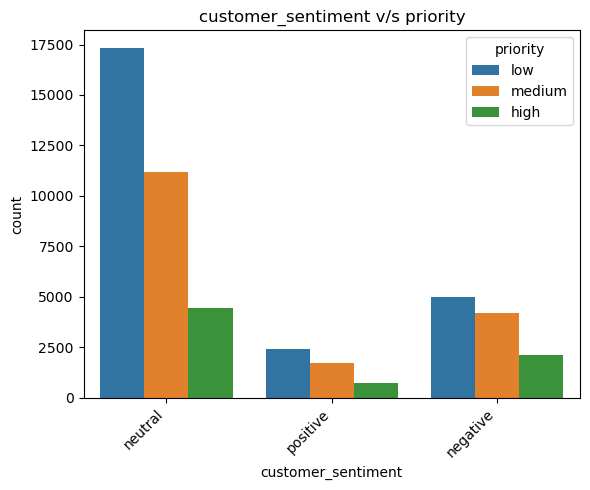

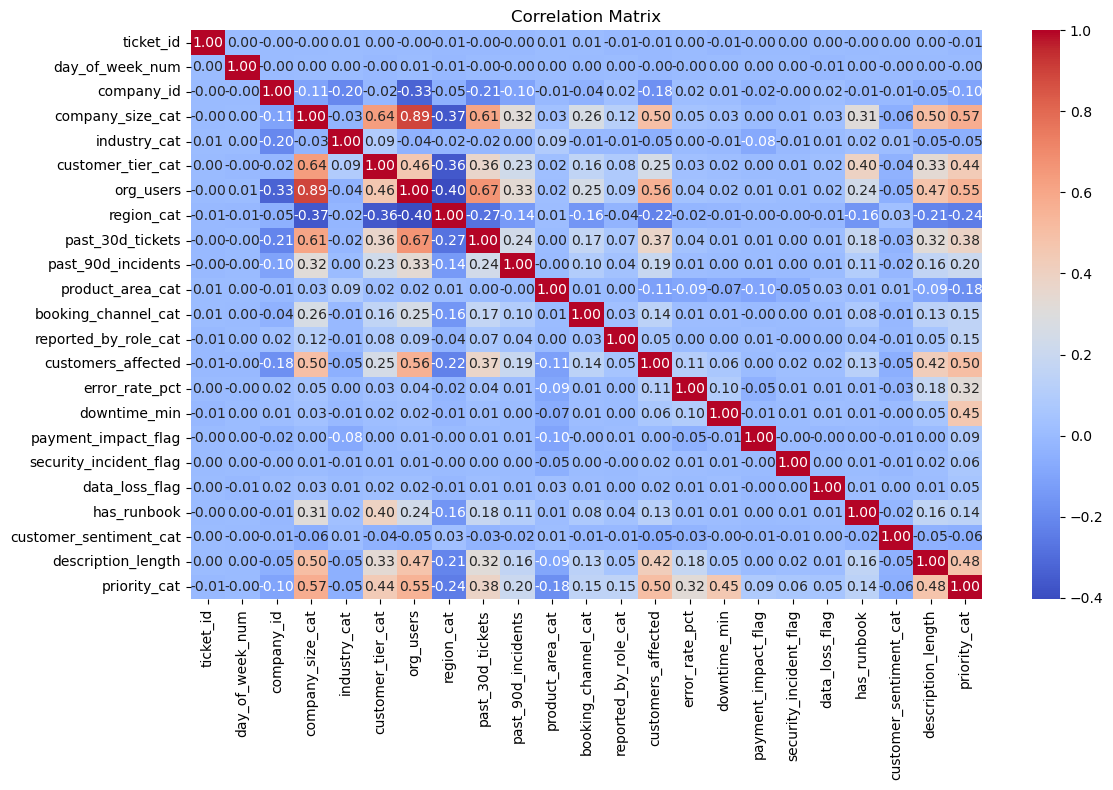

In [4]:
target_col = 'priority'
for col in categorical_col:
    if col!=target_col:
        plt.figure(figsize=(6,5))
        sns.countplot(data=ticket,x=col,hue=target_col)
        plt.xticks(rotation=45,ha='right')
        plt.title(f'{col} v/s {target_col}')
        plt.tight_layout()
        plt.show()

from utils.Evaluation_plot import correlation
correlation(ticket,numerical_col)

In [5]:
important_col=['company_size_cat','customer_tier_cat','org_users','past_30d_tickets','past_90d_incidents',
     'customers_affected','error_rate_pct','downtime_min','description_length']

In [6]:
from xgboost import XGBRegressor         
from sklearn.model_selection import train_test_split
from utils.Model_Selection import model_regression
X=ticket[important_col]
new_target='priority_cat'
y=ticket[new_target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
result_df=model_regression(X_train,X_test,y_train,y_test)
print(result_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 39275, number of used features: 9
[LightGBM] [Info] Start training from score 1.643819
           Model      RMSE        R2       MAE
4           LGBM  0.267169  0.866182  0.160413
2  random_forest  0.269816  0.863518  0.136986
3            XGB  0.271199  0.862115  0.163280
1  decision_tree  0.371206  0.741672  0.136776
0            SVR  0.424178  0.662683  0.310734


Training the Hyperparameter Tuning

Fitting 5 folds for each of 24 candidates, totalling 120 fits
best parameters:{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
best training scores:0.861
Feature Importance in XGB:



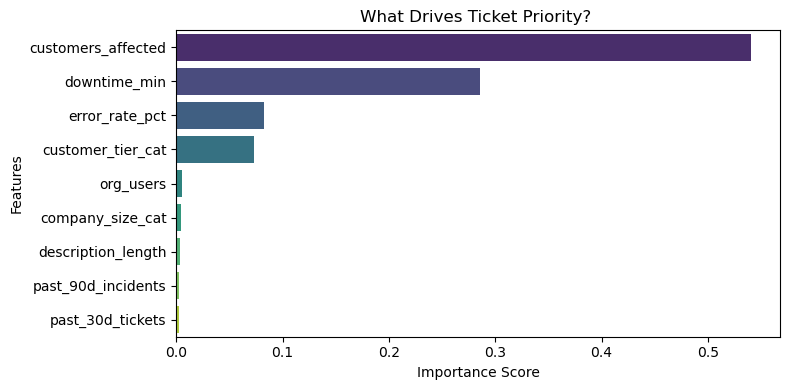

Residuals plot


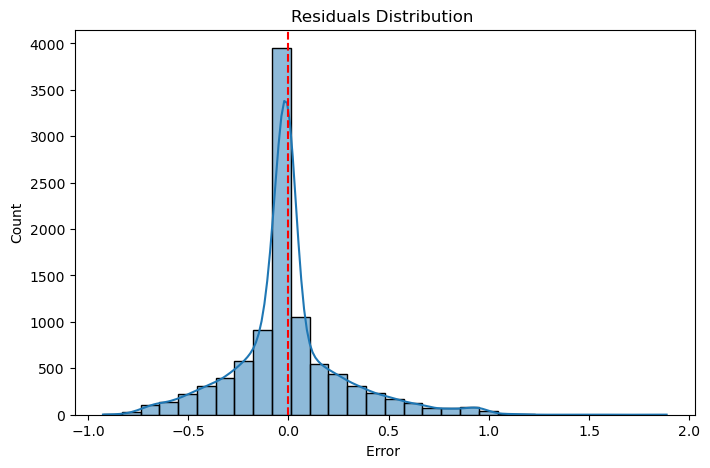

In [8]:
from utils.Hyperparameter import hyperparametertunning, param_grid_xgb
from utils.Evaluation_plot import featureimportance, correlation,residuals

model_xgb = XGBRegressor(n_jobs=-1, random_state=42)
xgb_params = param_grid_xgb() 
print("Training the Hyperparameter Tuning\n")
y_pred_xgb, importance_xgb = hyperparametertunning(model_xgb, 'r2', xgb_params, X_train, y_train, X_test)
print("Feature Importance in XGB:\n")
featureimportance(important_col, importance_xgb)
print("Residuals plot")
residuals(y_test,y_pred_xgb)